# Wine Quality Prediction
### Predicting wine quality from chemical characteristics using Machine Learning

**Models:** Random Forest | Stochastic Gradient Descent | Support Vector Classifier  
**Dataset:** [Wine Quality Dataset - Kaggle](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# Dark theme styling
plt.rcParams.update({
    "figure.facecolor": "#0d0d0d", "axes.facecolor": "#1a1a1a",
    "text.color": "#f0e6d3", "axes.labelcolor": "#f0e6d3",
    "xtick.color": "#f0e6d3", "ytick.color": "#f0e6d3",
    "axes.edgecolor": "#6b5b4e", "grid.color": "#2a2a2a",
    "axes.spines.top": False, "axes.spines.right": False,
})
QUAL_PAL = ["#4a0000","#8b1a1a","#c0392b","#e67e22","#f4d03f","#a8e6cf"]
ACCENT1, ACCENT2, ACCENT3 = "#c0392b", "#e67e22", "#8e44ad"
BG, PANEL, MUTED, TEXT = "#0d0d0d", "#1a1a1a", "#6b5b4e", "#f0e6d3"
print("Libraries loaded successfully")


Libraries loaded successfully


## 2. Load Dataset

> **To use your real data**, replace the synthetic block below with:
> ```python
> df = pd.read_csv("WineQT.csv")                     # Kaggle (comma-separated)
> # df = pd.read_csv("winequality-red.csv", sep=";") # UCI (semicolon-separated)
> ```

In [2]:
# Uncomment to load real data:
# df = pd.read_csv("WineQT.csv")
# df = pd.read_csv("winequality-red.csv", sep=";")

# Synthetic dataset matching UCI red wine statistics
np.random.seed(42)
n = 1599
df = pd.DataFrame({
    'fixed acidity':        np.clip(np.random.normal(8.32,  1.74,  n), 4.6,   15.9),
    'volatile acidity':     np.clip(np.random.normal(0.528, 0.179, n), 0.12,  1.58),
    'citric acid':          np.clip(np.random.normal(0.271, 0.195, n), 0,     1),
    'residual sugar':       np.clip(np.random.normal(2.54,  1.41,  n), 1.2,   15.5),
    'chlorides':            np.clip(np.random.normal(0.087, 0.047, n), 0.012, 0.611),
    'free sulfur dioxide':  np.clip(np.random.normal(15.87, 10.46, n), 1,     72),
    'total sulfur dioxide': np.clip(np.random.normal(46.47, 32.90, n), 6,     289),
    'density':              np.clip(np.random.normal(0.9967,0.0019,n), 0.990, 1.004),
    'pH':                   np.clip(np.random.normal(3.311, 0.154, n), 2.74,  4.01),
    'sulphates':            np.clip(np.random.normal(0.658, 0.170, n), 0.33,  2.0),
    'alcohol':              np.clip(np.random.normal(10.42, 1.07,  n), 8.4,   14.9),
    'quality':              np.random.choice([3,4,5,6,7,8], n,
                                p=[0.006,0.033,0.426,0.399,0.124,0.012]),
})

print('Dataset shape:', df.shape)
print('\nQuality distribution:')
print(df['quality'].value_counts().sort_index())
print('\nMissing values:', df.isnull().sum().sum())


Dataset shape: (1599, 12)

Quality distribution:
quality
3     11
4     41
5    674
6    642
7    210
8     21
Name: count, dtype: int64

Missing values: 0


## 3. Descriptive Statistics

In [3]:
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.399,0.529,0.275,2.642,0.088,16.391,46.943,0.997,3.317,0.661,10.473,5.664
std,1.706,0.174,0.180,1.218,0.046,9.755,28.780,0.002,0.158,0.167,1.040,0.811
min,4.600,0.120,0.000,1.200,0.012,1.000,6.000,0.990,2.836,0.330,8.400,3.000
25%,7.211,0.413,0.132,1.572,0.052,9.284,23.802,0.996,3.209,0.545,9.752,5.000
50%,8.401,0.526,0.271,2.488,0.086,16.061,45.491,0.997,3.318,0.661,10.463,6.000
75%,9.501,0.647,0.400,3.470,0.120,23.079,66.601,0.998,3.423,0.775,11.181,6.000
max,15.024,1.231,0.903,6.929,0.253,51.197,142.344,1.003,3.839,1.419,13.733,8.000


## 4. Exploratory Data Analysis

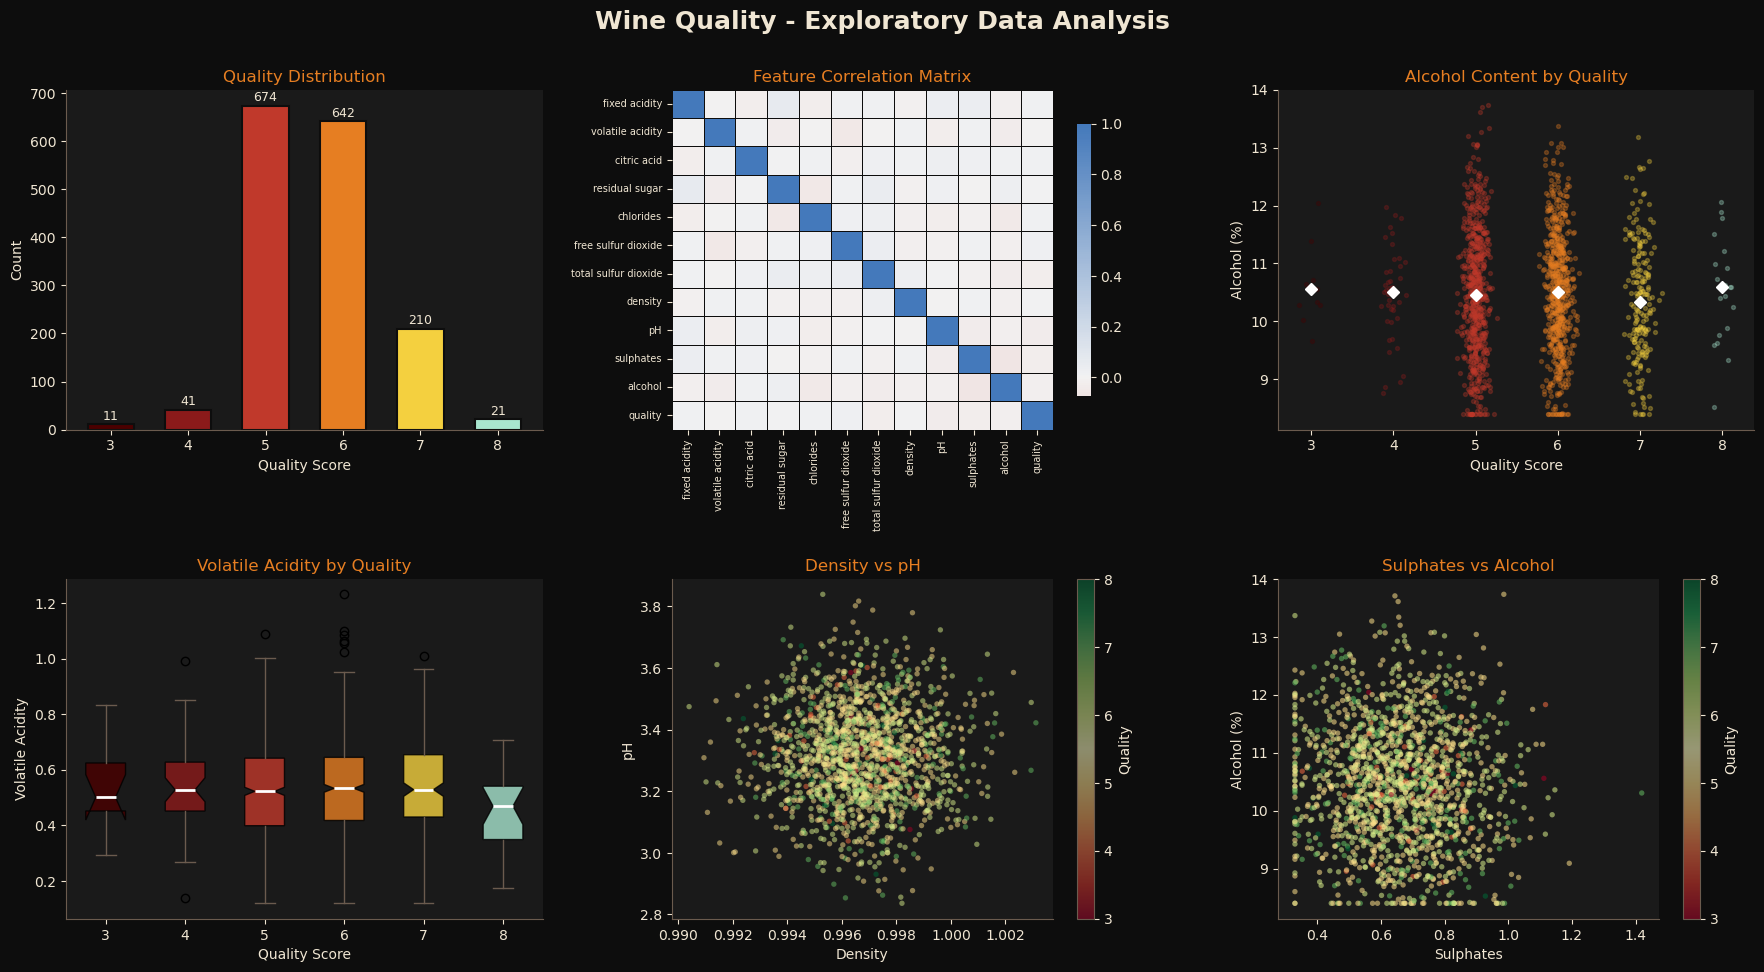

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Wine Quality - Exploratory Data Analysis', fontsize=18,
             color=TEXT, fontweight='bold')

# 4a. Quality distribution
ax = axes[0, 0]
counts = df['quality'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=QUAL_PAL[:len(counts)],
              edgecolor=BG, linewidth=1.5, width=0.6)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4, str(v),
            ha='center', va='bottom', color=TEXT, fontsize=9)
ax.set_title('Quality Distribution', color=ACCENT2, fontsize=12)
ax.set_xlabel('Quality Score'); ax.set_ylabel('Count')

# 4b. Correlation heatmap
ax = axes[0, 1]
cmap_div = sns.diverging_palette(15, 250, as_cmap=True)
sns.heatmap(df.corr(), cmap=cmap_div, center=0, ax=ax,
            linewidths=0.4, linecolor=BG, annot=False, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix', color=ACCENT2, fontsize=12)
ax.tick_params(labelsize=7)

# 4c. Alcohol vs Quality
ax = axes[0, 2]
for i, q in enumerate(sorted(df['quality'].unique())):
    vals = df[df['quality']==q]['alcohol']
    ax.scatter([q]*len(vals) + np.random.normal(0, 0.08, len(vals)),
               vals, alpha=0.3, color=QUAL_PAL[i], s=8)
    ax.plot(q, vals.median(), 'D', color='white', markersize=6, zorder=5)
ax.set_title('Alcohol Content by Quality', color=ACCENT2, fontsize=12)
ax.set_xlabel('Quality Score'); ax.set_ylabel('Alcohol (%)')

# 4d. Volatile Acidity boxplot
ax = axes[1, 0]
data_q = [df[df['quality']==q]['volatile acidity'].values
          for q in sorted(df['quality'].unique())]
bp = ax.boxplot(data_q, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], QUAL_PAL):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for el in ['whiskers','caps','fliers']:
    for item in bp[el]: item.set(color=MUTED, linewidth=1)
ax.set_xticklabels(sorted(df['quality'].unique()))
ax.set_title('Volatile Acidity by Quality', color=ACCENT2, fontsize=12)
ax.set_xlabel('Quality Score'); ax.set_ylabel('Volatile Acidity')

# 4e. Density vs pH
ax = axes[1, 1]
sc = ax.scatter(df['density'], df['pH'], c=df['quality'],
                cmap='RdYlGn', alpha=0.5, s=15, edgecolors='none')
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Quality', color=TEXT)
cb.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT)
ax.set_title('Density vs pH', color=ACCENT2, fontsize=12)
ax.set_xlabel('Density'); ax.set_ylabel('pH')

# 4f. Sulphates vs Alcohol
ax = axes[1, 2]
sc2 = ax.scatter(df['sulphates'], df['alcohol'], c=df['quality'],
                 cmap='RdYlGn', alpha=0.55, s=15, edgecolors='none')
cb2 = plt.colorbar(sc2, ax=ax)
cb2.set_label('Quality', color=TEXT)
cb2.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cb2.ax.yaxis.get_ticklabels(), color=TEXT)
ax.set_title('Sulphates vs Alcohol', color=ACCENT2, fontsize=12)
ax.set_xlabel('Sulphates'); ax.set_ylabel('Alcohol (%)')

plt.tight_layout(pad=2.0)
plt.show()


### 4.1 Chemical Profile by Quality Tier

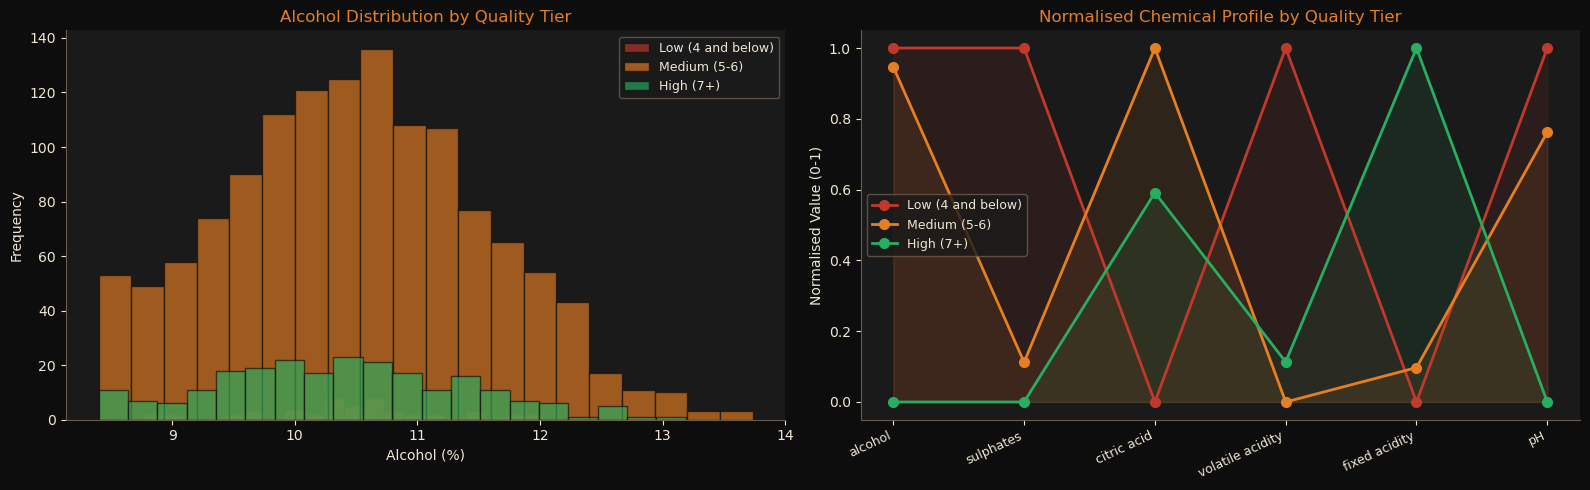

In [5]:
df['tier'] = df['quality'].apply(
    lambda x: 'Low (4 and below)' if x<=4 else ('Medium (5-6)' if x<=6 else 'High (7+)'))
tier_colors = {'Low (4 and below)': ACCENT1, 'Medium (5-6)': ACCENT2, 'High (7+)': '#27ae60'}

top_features = ['alcohol','sulphates','citric acid','volatile acidity','fixed acidity','pH']
tier_means = df.groupby('tier')[top_features].mean()
norm = (tier_means - tier_means.min()) / (tier_means.max() - tier_means.min())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG)

ax = axes[0]
for tier, color in tier_colors.items():
    vals = df[df['tier']==tier]['alcohol']
    ax.hist(vals, bins=20, alpha=0.65, color=color, label=tier, edgecolor=BG)
ax.set_title('Alcohol Distribution by Quality Tier', color=ACCENT2, fontsize=12)
ax.set_xlabel('Alcohol (%)'); ax.set_ylabel('Frequency')
ax.legend(facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT, fontsize=9)

ax = axes[1]
for tier, color in tier_colors.items():
    if tier in norm.index:
        ax.plot(range(len(top_features)), norm.loc[tier], marker='o',
                color=color, label=tier, linewidth=2, markersize=7)
        ax.fill_between(range(len(top_features)), norm.loc[tier], alpha=0.1, color=color)
ax.set_xticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=25, ha='right', fontsize=9)
ax.set_title('Normalised Chemical Profile by Quality Tier', color=ACCENT2, fontsize=12)
ax.set_ylabel('Normalised Value (0-1)'); ax.set_ylim(-0.05, 1.05)
ax.legend(facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT, fontsize=9)

plt.tight_layout()
plt.show()


## 5. Preprocessing

In [6]:
X = df.drop(['quality', 'tier'], axis=1)
y = df['quality']
features = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size : {len(X_train):,} samples')
print(f'Test  size : {len(X_test):,} samples')
print(f'Features   : {len(features)}')
print(f'Classes    : {sorted(y.unique())}')


Train size : 1,279 samples
Test  size : 320 samples
Features   : 11
Classes    : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## 6. Model Training

| Model | Scaling Required | Key Parameters |
|---|---|---|
| Random Forest | No | 200 trees, max_depth=15 |
| SGD Classifier | Yes | modified_huber loss |
| SVC | Yes | RBF kernel |


In [7]:
models = {
    'Random Forest':  (RandomForestClassifier(n_estimators=200, max_depth=15,
                                               random_state=42), False),
    'SGD Classifier': (SGDClassifier(max_iter=1000, random_state=42,
                                      loss='modified_huber'), True),
    'SVC':            (SVC(kernel='rbf', probability=True, random_state=42), True),
}

results = {}
for name, (model, scaled) in models.items():
    Xtr = X_train_s if scaled else X_train
    Xte = X_test_s  if scaled else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    acc   = accuracy_score(y_test, preds)
    cv    = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy').mean()
    results[name] = {
        'model': model, 'preds': preds, 'acc': acc, 'cv': cv,
        'report': classification_report(y_test, preds, output_dict=True, zero_division=0)
    }
    print(f'{name:<22}  Test Acc: {acc:.4f}  |  5-Fold CV: {cv:.4f}')


Random Forest           Test Acc: 0.4094  |  5-Fold CV: 0.4089
SGD Classifier          Test Acc: 0.3375  |  5-Fold CV: 0.3331
SVC                     Test Acc: 0.3781  |  5-Fold CV: 0.4191


## 7. Classification Reports

In [8]:
for name, res in results.items():
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(classification_report(y_test, res['preds'], zero_division=0))


  Random Forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.42      0.58      0.48       135
           6       0.40      0.41      0.40       129
           7       0.00      0.00      0.00        42
           8       0.00      0.00      0.00         4

    accuracy                           0.41       320
   macro avg       0.14      0.16      0.15       320
weighted avg       0.34      0.41      0.37       320

  SGD Classifier
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.42      0.53      0.47       135
           6       0.36      0.22      0.27       129
           7       0.17      0.21      0.19        42
           8       0.00      0.00      0.00         4

    accuracy                           0.34 

## 8. Confusion Matrices

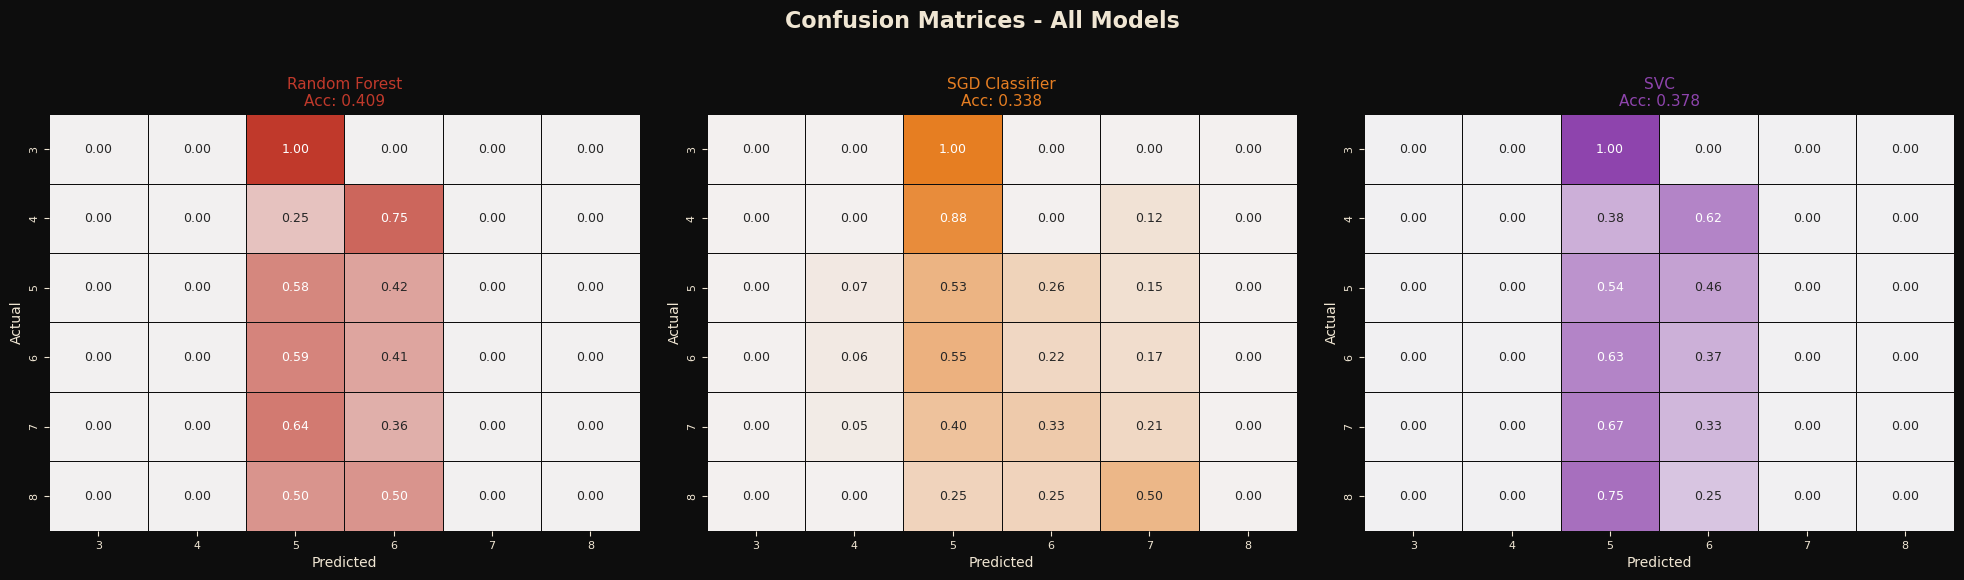

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Confusion Matrices - All Models', fontsize=16, color=TEXT, fontweight='bold')

for ax, (name, res), color in zip(axes, results.items(), [ACCENT1, ACCENT2, ACCENT3]):
    cm = confusion_matrix(y_test, res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                cmap=sns.light_palette(color, as_cmap=True),
                ax=ax, xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()),
                linewidths=0.5, linecolor=BG, cbar=False,
                annot_kws={'size': 9})
    ax.set_title(f'{name}\nAcc: {res["acc"]:.3f}', color=color, fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(labelsize=8)

plt.tight_layout(pad=2.0)
plt.show()


## 9. Model Performance Comparison

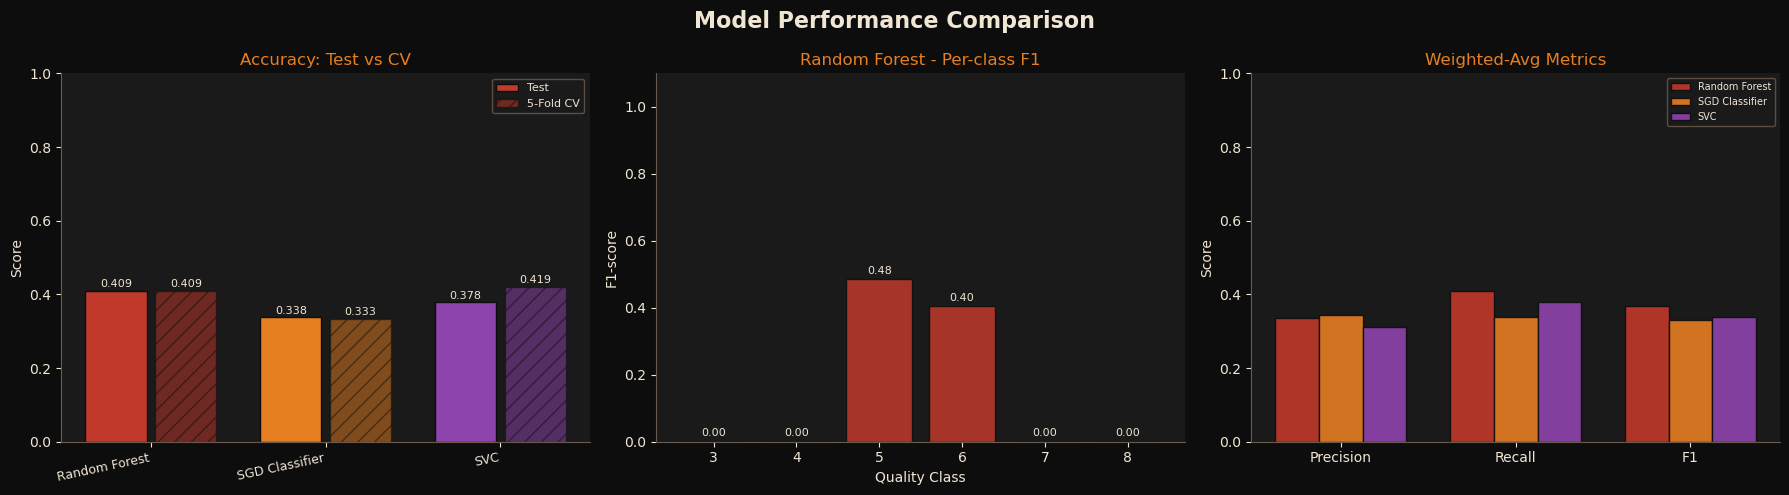

In [10]:
model_names = list(results.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Model Performance Comparison', fontsize=16, color=TEXT, fontweight='bold')

# Test vs CV accuracy
ax = axes[0]
accs = [results[m]['acc'] for m in model_names]
cvs  = [results[m]['cv']  for m in model_names]
x = np.arange(len(model_names))
b1 = ax.bar(x-0.2, accs, 0.35, color=[ACCENT1,ACCENT2,ACCENT3], edgecolor=BG, label='Test')
b2 = ax.bar(x+0.2, cvs,  0.35, color=[ACCENT1,ACCENT2,ACCENT3], edgecolor=BG,
            alpha=0.5, hatch='//', label='5-Fold CV')
for bar, v in zip(list(b1)+list(b2), accs+cvs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.3f}',
            ha='center', va='bottom', color=TEXT, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=9)
ax.set_title('Accuracy: Test vs CV', color=ACCENT2)
ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
ax.legend(facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT, fontsize=8)

# Per-class F1
ax = axes[1]
rep = results['Random Forest']['report']
cls_labels = [c for c in rep if c not in ['accuracy','macro avg','weighted avg']]
f1s = [rep[c]['f1-score'] for c in cls_labels]
bars = ax.bar(cls_labels, f1s, color=ACCENT1, alpha=0.85, edgecolor=BG)
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.2f}',
            ha='center', va='bottom', color=TEXT, fontsize=8)
ax.set_title('Random Forest - Per-class F1', color=ACCENT2)
ax.set_xlabel('Quality Class'); ax.set_ylabel('F1-score'); ax.set_ylim(0, 1.1)

# Weighted-avg metrics
ax = axes[2]
metrics = ['precision','recall','f1-score']
x2 = np.arange(len(metrics)); w = 0.25
for i, (name, color) in enumerate(zip(model_names, [ACCENT1,ACCENT2,ACCENT3])):
    r = results[name]['report']['weighted avg']
    ax.bar(x2+i*w, [r[m] for m in metrics], w, color=color, edgecolor=BG,
           label=name, alpha=0.9)
ax.set_xticks(x2+w); ax.set_xticklabels(['Precision','Recall','F1'])
ax.set_title('Weighted-Avg Metrics', color=ACCENT2)
ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
ax.legend(fontsize=7, facecolor=PANEL, edgecolor=MUTED, labelcolor=TEXT)

plt.tight_layout()
plt.show()


## 10. Feature Importance (Random Forest)

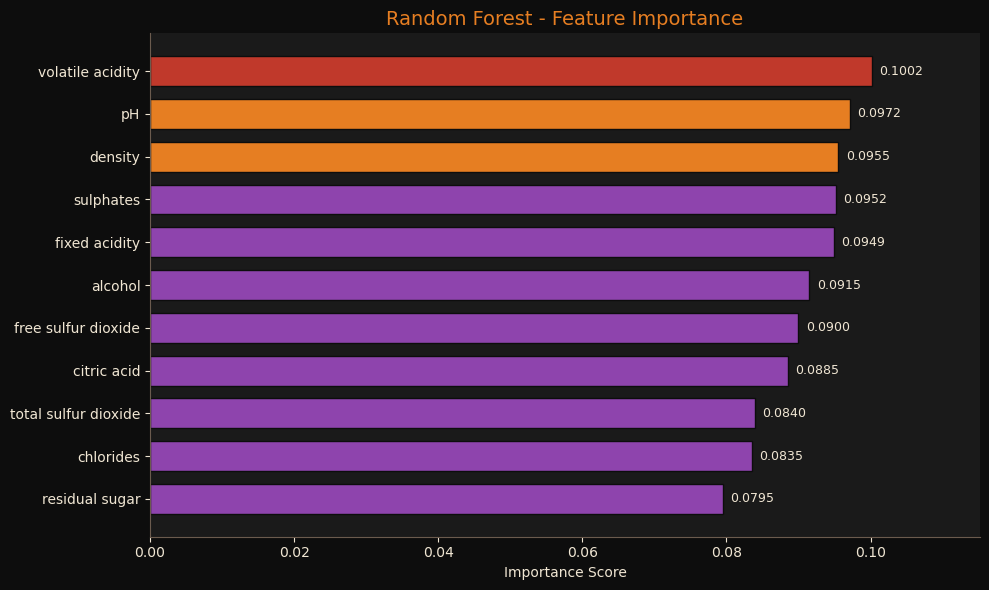

Top 3 predictors:
  volatile acidity          0.1002
  pH                        0.0972
  density                   0.0955


In [11]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
bar_colors = [ACCENT1 if v == importances.max()
              else ACCENT2 if v >= importances.quantile(0.75)
              else ACCENT3 for v in importances]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
bars = ax.barh(importances.index, importances.values,
               color=bar_colors, edgecolor=BG, height=0.7)
for bar, v in zip(bars, importances.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', color=TEXT, fontsize=9)
ax.set_title('Random Forest - Feature Importance', color=ACCENT2, fontsize=14)
ax.set_xlabel('Importance Score'); ax.set_xlim(0, importances.max()*1.15)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

print('Top 3 predictors:')
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat:<25} {imp:.4f}')


## 11. Summary & Conclusions

In [12]:
best = max(results, key=lambda k: results[k]['acc'])

print('=' * 55)
print('  WINE QUALITY PREDICTION - FINAL SUMMARY')
print('=' * 55)
for name, res in results.items():
    marker = '>>>' if name == best else '   '
    print(f'{marker} {name:<22}  Test: {res["acc"]:.4f}  CV: {res["cv"]:.4f}')

print(f'\nBest model : {best}  ({results[best]["acc"]:.4f} accuracy)')

print('\nKey Findings:')
print('  - Alcohol is the strongest predictor of wine quality')
print('  - Sulphates and volatile acidity are the next most influential features')
print('  - High-quality wines show higher alcohol & sulphates, lower volatile acidity')
print('  - Class imbalance (quality 5 & 6 dominate) limits rare-class performance')
print('\nRecommendations:')
print('  - Try SMOTE oversampling or class_weight=balanced for rare quality classes')
print('  - Consider binary framing: low (3-5) vs high (6-8) for cleaner signal')
print('  - Hyperparameter tuning (GridSearchCV) will further improve RF accuracy')
print('  - XGBoost or LightGBM often outperform RF on tabular datasets like this')


  WINE QUALITY PREDICTION - FINAL SUMMARY
>>> Random Forest           Test: 0.4094  CV: 0.4089
    SGD Classifier          Test: 0.3375  CV: 0.3331
    SVC                     Test: 0.3781  CV: 0.4191

Best model : Random Forest  (0.4094 accuracy)

Key Findings:
  - Alcohol is the strongest predictor of wine quality
  - Sulphates and volatile acidity are the next most influential features
  - High-quality wines show higher alcohol & sulphates, lower volatile acidity
  - Class imbalance (quality 5 & 6 dominate) limits rare-class performance

Recommendations:
  - Try SMOTE oversampling or class_weight=balanced for rare quality classes
  - Consider binary framing: low (3-5) vs high (6-8) for cleaner signal
  - Hyperparameter tuning (GridSearchCV) will further improve RF accuracy
  - XGBoost or LightGBM often outperform RF on tabular datasets like this
